In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install neuroCombat

  Preparing metadata (setup.py) ... done
  Created wheel for neuroCombat: filename=neuroCombat-0.2.12-py3-none-any.whl size=6353 sha256=50fc35492840b571c1e43acd258076a34758f50bd045be2d26cf5c16488055ac
  Stored in directory: /root/.cache/pip/wheels/ab/b2/ba/67ac62c94b5e0adc9bdb835456277052f698d6605a99614cd2
Successfully built neuroCombat


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.svm import SVR
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_curve, auc
from neuroCombat import neuroCombat
import statsmodels.api as sm



In [ ]:
male_df = pd.read_csv('/content/drive/MyDrive/Thesis_May20th/male_data_updated.csv')

female_covars = {
    "batch": male_df['site_id'],
    "age": male_df['age']
}

covars = pd.DataFrame(female_covars)

columns_to_harmonize = male_df.columns[5:154]  # Adjust or use column names
fdata_to_harmonize = male_df[columns_to_harmonize].values.T

# neuroCombat
data_harmonized_male = neuroCombat(
    dat=fdata_to_harmonize,
    covars=covars,
    eb=False,
    continuous_cols=["age"],
    batch_col="batch"
)["data"].T


[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding L/S adjustments without Empirical Bayes
[neuroCombat] Final adjustment of data


In [ ]:
print(data_harmonized_male.shape)


(3068, 149)


In [ ]:
print("Harmonized data shape:", data_harmonized_male.shape)
print("Original data shape:", male_df.shape)


Harmonized data shape: (3068, 149)
Original data shape: (3068, 155)


In [ ]:
harmonized_df = pd.DataFrame(data_harmonized_male, columns=columns_to_harmonize, index=male_df.index)


In [ ]:
male_df.update(harmonized_df)


In [ ]:
print(male_df.head())


   Unnamedd  age  gender  site_id  diagnosis  L_G.S_cingul.Ant  \
0         1   26       1        0          0          2.785973   
1         2   18       1        0          0          3.091927   
2         3   29       1        0          0          2.876269   
3         4   31       1        0          0          2.798669   
4         5   14       1        0          0          3.027096   

   L_G.S_cingul.Mid.Ant  L_G.S_cingul.Mid.Post  L_G.S_frontomargin  \
0              2.612075               2.749071            2.418609   
1              2.768408               2.741085            2.171017   
2              2.670593               2.695015            2.461815   
3              2.628854               2.549206            2.236924   
4              2.849762               2.733581            2.712639   

   L_G.S_occipital_inf  ...  R_S_postcentral  R_S_precentral.inf.part  \
0             2.206498  ...         2.057667                 2.406845   
1             2.432491  ...         

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

diagnosis_0_data = male_df[male_df['diagnosis'] == 0]

diagnosis_not_0_data = male_df[male_df['diagnosis'].isin([1, 2, 3, 4, 5])]

train_data = diagnosis_0_data.copy()

test_data = diagnosis_not_0_data.copy()

train_size = len(train_data)
test_size = len(test_data)

print("Training set size:", train_size)
print("Test set size:", test_size)


Training set size: 2782
Test set size: 286


In [ ]:
features = [col for col in train_data.columns if col != 'age']
X_train = train_data[features]
y_train = train_data['age']
X_test = test_data[features]
y_test = test_data['age']


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
features = male_df.drop('age', axis=1)

numerical_columns = features.select_dtypes(include=['int64', 'float64']).columns.tolist()

imputer = SimpleImputer(strategy='median')
features[numerical_columns] = imputer.fit_transform(features[numerical_columns])


scaler = StandardScaler()
features[numerical_columns] = scaler.fit_transform(features[numerical_columns])




In [ ]:
imputer = SimpleImputer(strategy='mean')
train_data[numerical_columns] = imputer.fit_transform(train_data[numerical_columns])
test_data[numerical_columns] = imputer.transform(test_data[numerical_columns])

In [ ]:
min_max_scaler = MinMaxScaler()
train_data[numerical_columns] = min_max_scaler.fit_transform(train_data[numerical_columns])
test_data[numerical_columns] = min_max_scaler.transform(test_data[numerical_columns])


# New XGBoost + K-Fold

In [ ]:
xg_reg = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=3, seed=42)

xg_reg.fit(X_train, y_train)

y_pred = xg_reg.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r_squared = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-squared: {r_squared}")
print(f'Mean Squared Error: {mse}')

Root Mean Squared Error (RMSE): 7.36664174396889
Mean Absolute Error (MAE): 5.901622785554899
R-squared: 0.8827663862126605
Mean Squared Error: 54.267410583985


MSE scores: [142.4389168141225, 129.64913205320954, 484.06797019950176, 41.86980575552286, 42.88480159381994, 52.56503077274837, 57.875219559215516, 65.14050693093724, 209.443123339889, 70.31232340645953]
Average MSE: 129.6246830425426
MAE scores: [11.487125383682356, 10.567309646681686, 18.83067316379187, 5.303220630616181, 5.177252913966323, 5.562204153878349, 5.951478368357608, 5.994866634670057, 11.009615440891213, 6.6252159907900054]


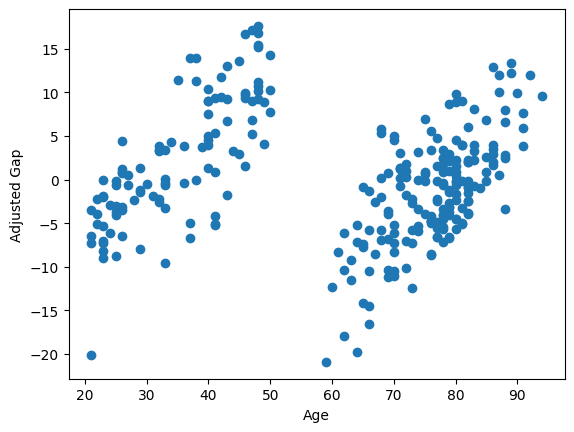

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error
import statsmodels.api as sm
import matplotlib.pyplot as plt


imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Group K-Fold
gkf = GroupKFold(n_splits=10)

groups = X_train['site_id']  # Ensure 'site_id' is available in your X_train

mse_scores = []
mae_scores = []

for train_index, test_index in gkf.split(X_train_imputed, y_train, groups):
    X_train_cv, X_test_cv = X_train_imputed[train_index], X_train_imputed[test_index]
    y_train_cv, y_test_cv = y_train.iloc[train_index], y_train.iloc[test_index]

    X_train_cv = np.nan_to_num(X_train_cv)
    X_test_cv = np.nan_to_num(X_test_cv)
    y_train_cv = y_train_cv.fillna(y_train_cv.mean())
    y_test_cv = y_test_cv.fillna(y_test_cv.mean())

    xg_reg = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=3, seed=42)
    xg_reg.fit(X_train_cv, y_train_cv)

    y_pred_cv = xg_reg.predict(X_test_cv)

    mse = mean_squared_error(y_test_cv, y_pred_cv)
    mae = mean_absolute_error(y_test_cv, y_pred_cv)
    mse_scores.append(mse)
    mae_scores.append(mae)

print("MSE scores:", mse_scores)
print("Average MSE:", np.mean(mse_scores))
print("MAE scores:", mae_scores)

xg_reg.fit(X_train_imputed, y_train)
y_pred = xg_reg.predict(X_test_imputed)
gap = y_test - y_pred

age_with_intercept = sm.add_constant(test_data['age'], prepend=False)
mod = sm.OLS(gap, age_with_intercept)
gap_adjusted = mod.fit().resid

plt.scatter(test_data['age'], gap_adjusted)
plt.xlabel('Age')
plt.ylabel('Adjusted Gap')
plt.show()


In [ ]:
male_df.loc[y_test.index, 'gap'] = gap

In [ ]:
#data['residuals'] = data['residuals'].fillna(data['residuals'].median())

male_df['gap'] = male_df['gap'].fillna(male_df['gap'].mean())


In [ ]:
import pandas as pd
from sklearn.metrics import roc_auc_score


for i in range(1, 6):
    male_df[f'diagnosis_{i}_vs_0'] = (male_df['diagnosis'] == i).astype(int)

roc_auc_scores = {}
for i in range(1, 6):
    condition = male_df['diagnosis'].isin([0, i])
    roc_auc_scores[f'ROC AUC for 0 vs {i}'] = roc_auc_score(male_df.loc[condition, f'diagnosis_{i}_vs_0'], male_df.loc[condition, 'gap'])

for key, value in roc_auc_scores.items():
    print(f"{key}: {value:.2f}")


ROC AUC for 0 vs 1: 0.46
ROC AUC for 0 vs 2: 0.50
ROC AUC for 0 vs 3: 0.49
ROC AUC for 0 vs 4: 0.48
ROC AUC for 0 vs 5: 0.74
